In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU.")
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")
#model.to(device)

Using GPU.


In [3]:
class BertRegressor(nn.Module):
    def __init__(self, drop_rate=0.1, freeze_bert_layers=True, n_unfrozen_layers=2):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-multilingual-cased")

        if freeze_bert_layers:
            # Freeze all layers first
            for param in self.bert.parameters():
                param.requires_grad = False

            # Unfreeze last `n_unfrozen_layers` transformer blocks
            for layer in self.bert.transformer.layer[-n_unfrozen_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True

        self.regressor = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(self.bert.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0]  # CLS token
        return self.regressor(cls_embedding)

In [4]:
import pickle

# Ensure the model class definition is already in your script
with open("/kaggle/input/reviews_bert/pytorch/default/1/reviews_model.pkl", "rb") as f:
    reviews_model = pickle.load(f)

reviews_model.to(device)
reviews_model.eval()


2025-07-14 16:15:27.424422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752509727.605711      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752509727.662935      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


BertRegressor(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(

In [5]:
reviews = pd.read_csv("/kaggle/input/reviews/reviews_priced.csv")  # venice listings
reviews = reviews[~reviews["price"].isna()]


In [6]:
import torch

def predict(model, dataloader, device):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, _ = [b.to(device) for b in batch]

            outputs = model(input_ids, attention_mask)
            outputs = outputs.squeeze().detach().cpu().numpy()

            all_preds.extend(outputs)

    return np.array(all_preds)


In [7]:
# Complete text-cleaning function for BERT
import re
import html
import unicodedata

def text_cleaning(text):
     # Normalize unicode chars
    text = unicodedata.normalize("NFKC", text)

    # Unescape HTML entities 
    text = html.unescape(text)

    # Replace non-breaking spaces and weird unicode chars
    text = text.replace(u'\xa0', ' ').replace(u'\u200b', '')

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace(u'\xa0', u' ') # Replace non-breaking space with normal space
    return text

In [8]:
reviews = reviews.copy()
reviews.loc[:, 'clean_review'] = reviews.comments.fillna('').apply(text_cleaning)


In [9]:
split_ids = int(reviews.shape[0] * 0.8)
reviews_df = reviews.iloc[:split_ids, :].reset_index(drop=True)
reviews_df_test = reviews.iloc[split_ids:, :].reset_index(drop=True)


In [10]:
# Tokenization
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-multilingual-cased")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

In [11]:
encoded_corpus = tokenizer(text=reviews_df.clean_review.tolist(),
                        add_special_tokens=True,
                        padding='max_length',
                        truncation='longest_first',
                        max_length=512,
                        return_attention_mask=True)

input_ids = encoded_corpus['input_ids']
attention_mask = encoded_corpus['attention_mask']

In [12]:
# Review indicies
reviews_ids = np.arange(len(reviews_df))

input_ids = np.array(input_ids)[reviews_ids]
attention_mask = np.array(attention_mask)[reviews_ids]

# Log transform price column
labels = np.log1p(reviews_df['price'].to_numpy())

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
test_size = 0.2
seed = 42
train_inputs, val_inputs, train_labels, val_labels = \
            train_test_split(input_ids, labels, test_size=test_size,
                             random_state=seed)



In [14]:
from sklearn.preprocessing import StandardScaler
price_scaler = StandardScaler()
price_scaler.fit(val_labels.reshape(-1, 1))


StandardScaler()

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader
batch_size = 64
def create_dataloaders(inputs, masks, labels, batch_size):
    input_tensor = torch.tensor(inputs)
    mask_tensor = torch.tensor(masks)
    labels_tensor = torch.tensor(labels)
    dataset = TensorDataset(input_tensor, mask_tensor,
                            labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=True)
    return dataloader

In [16]:
price_scaler.fit(val_labels.reshape(-1, 1))

StandardScaler()

In [17]:
# Test dataset prepration
test_encoded = tokenizer(
    text=reviews_df_test["clean_review"].tolist(),
    add_special_tokens=True,
    padding='max_length',
    truncation='longest_first',
    max_length=512,
    return_attention_mask=True
)
test_input_ids = np.array(test_encoded['input_ids'])
test_attention_mask = np.array(test_encoded['attention_mask'])
test_labels = np.log1p(reviews_df_test["price"].to_numpy())
price_scaler.fit(test_labels.reshape(-1, 1))
test_labels = price_scaler.transform(test_labels.reshape(-1, 1))

#test_dataloader = create_dataloaders(test_input_ids, test_attention_mask, test_labels)
test_dataloader = create_dataloaders(test_input_ids, test_attention_mask, test_labels, batch_size=batch_size)

In [18]:
y_pred = predict(reviews_model, test_dataloader, device)
y_pred = price_scaler.inverse_transform(y_pred.reshape(-1, 1))
#y_pred = np.expm1(y_pred)
y_test = price_scaler.inverse_transform(test_labels.reshape(-1, 1))
#y_test = np.expm1(y_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# R squared Score
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.55
Mean Squared Error (MSE): 0.51
R^2 Score: -0.5469


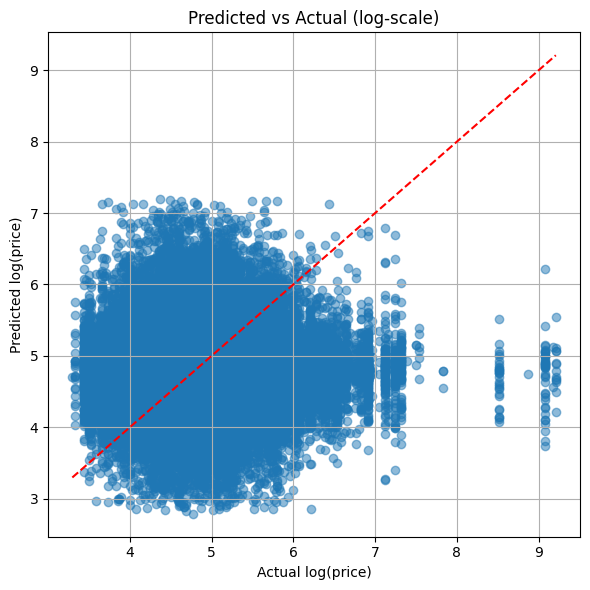

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(price)')
plt.ylabel('Predicted log(price)')
plt.title('Predicted vs Actual (log-scale)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:

# Ensure the model class definition is already in your script
with open("/kaggle/input/reviews_bert/pytorch/default/1/reviews_model.pkl", "rb") as f:
    descriptions_model = pickle.load(f)

descriptions_model.to(device)
descriptions_model.eval()

BertRegressor(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(

In [22]:
descriptions = pd.read_csv("/kaggle/input/listings-clean/listings.csv")  # venice listings
descriptions = descriptions[~descriptions["price"].isna()]
descriptions = descriptions[['id',
 'description',
 'price']]
descriptions.loc[:,'price'] = descriptions['price'].str.replace('$', '')
descriptions.loc[:,'price'] = descriptions['price'].str.replace(',', '')
descriptions = descriptions.astype({'price':'float'})

In [23]:
# Cleaning of descriptions column
descriptions = descriptions.copy()
descriptions.loc[:, 'clean_description'] = descriptions.description.fillna('').apply(text_cleaning)

In [24]:
split_ids = int(descriptions.shape[0] * 0.8)
descriptions_df = descriptions.iloc[:split_ids, :].reset_index(drop=True)
descriptions_df_test = descriptions.iloc[split_ids:, :].reset_index(drop=True)

In [25]:
descriptions_ids = np.arange(len(descriptions_df))

input_ids = np.array(input_ids)[descriptions_ids]
attention_mask = np.array(attention_mask)[descriptions_ids]

# Log transform price column
labels = np.log1p(descriptions_df['price'].to_numpy())

In [26]:
test_size = 0.2
seed = 42
train_inputs, val_inputs, train_labels, val_labels = \
            train_test_split(input_ids, labels, test_size=test_size,
                             random_state=seed)
train_masks, val_masks, _, _ = train_test_split(attention_mask,
                                        labels, test_size=test_size,
                                        random_state=seed)

In [27]:
price_scaler = StandardScaler()
price_scaler.fit(val_labels.reshape(-1, 1))

StandardScaler()

In [28]:
# Test dataset prepration
test_encoded = tokenizer(
    text=descriptions_df_test["clean_description"].tolist(),
    add_special_tokens=True,
    padding='max_length',
    truncation='longest_first',
    max_length=512,
    return_attention_mask=True
)
test_input_ids = np.array(test_encoded['input_ids'])
test_attention_mask = np.array(test_encoded['attention_mask'])
test_labels = np.log1p(descriptions_df_test["price"].to_numpy())
test_labels = price_scaler.transform(test_labels.reshape(-1, 1))

#test_dataloader = create_dataloaders(test_input_ids, test_attention_mask, test_labels)
test_dataloader = create_dataloaders(test_input_ids, test_attention_mask, test_labels, batch_size=batch_size)

In [29]:
y_pred = predict(descriptions_model, test_dataloader, device)
y_pred = price_scaler.inverse_transform(y_pred.reshape(-1, 1))
#y_pred = np.expm1(y_pred)
y_test = price_scaler.inverse_transform(test_labels.reshape(-1, 1))
#y_test = np.expm1(y_test)

In [30]:
# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# R squared Score
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.67
Mean Squared Error (MSE): 0.74
R^2 Score: -0.5537


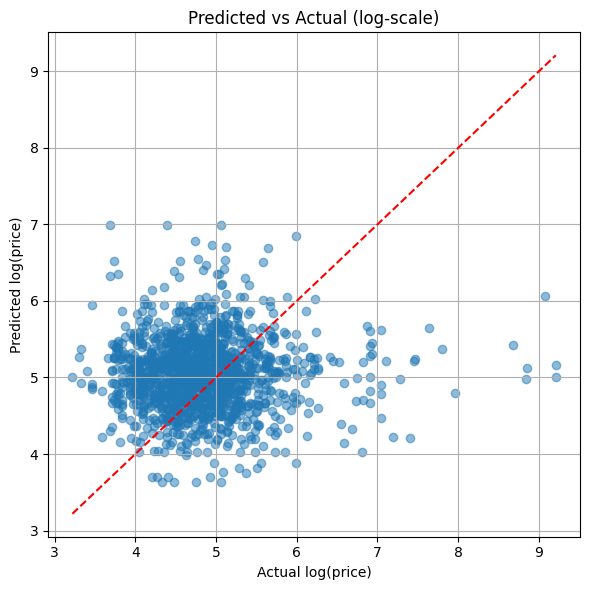

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(price)')
plt.ylabel('Predicted log(price)')
plt.title('Predicted vs Actual (log-scale)')
plt.grid(True)
plt.tight_layout()
plt.show()